<a href="https://colab.research.google.com/github/irpray/subtim-aset/blob/main/Rekap_Data_Berita_Infopublik_(Jan_Nov_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/rekap_berita.xlsx'
df = pd.read_excel(file_path)

# Basic info
print("Struktur Data:")
display(df.info())
display(df.head())

Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40165 entries, 0 to 40164
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   tanggal           40165 non-null  datetime64[ns]
 1   kategori          40165 non-null  object        
 2   judul             40165 non-null  object        
 3   deskripsi_berita  40164 non-null  object        
 4   isi_berita        40164 non-null  object        
 5   penulis           40165 non-null  object        
 6   redaktur          40165 non-null  object        
 7   page_view         40165 non-null  int64         
 8   link              40165 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 2.8+ MB


None

,tanggal,kategori,judul,deskripsi_berita,isi_berita,penulis,redaktur,page_view,link
0,2025-01-01 01:04:53,Nusantara,Kemenag Sumenep Luncurkan Aplikasi KPRI Al-Ikh...,Kepala Kementerian Agama (Kemenag) Kabupaten S...,"<p style=""text-align: justify;""><strong>Sumene...",MC KAB SUMENEP,Juli,287,https://infopublik.id/kategori/nusantara/89626...
1,2025-01-01 01:07:10,Nusantara,"Meriahkan HAB ke-79, Kemenag Sumenep Gelar Lom...",Dalam rangka memperingati Hari Amal Bhakti (HA...,"<p style=""text-align: justify;""><strong>Sumene...",MC KAB SUMENEP,Juli,291,https://infopublik.id/kategori/nusantara/89626...
2,2025-01-01 05:12:44,Nusantara,Bupati Tuban Bersama Forkopimda Gelar Patroli ...,"Bupati Tuban, Aditya Halindra Faridzky, bersam...","<div id=""m#msg-a:r9043651046182226598"" class=""...",MC KAB TUBAN,Juli,2227,https://infopublik.id/kategori/nusantara/89626...
3,2025-01-01 08:54:36,Nusantara,Pj Bupati Batang: Harmoni Antaragama Kunci Kem...,Kabupaten Batang menggelar doa lintas agama di...,"<p class=""p1"" style=""text-align: justify;""><st...",MC KAB BATANG,Tri Antoro,262,https://infopublik.id/kategori/nusantara/89626...
4,2025-01-01 09:04:36,Nusantara,"Universal Health Coverage di Batang, Bukti Nya...","Pj Bupati Batang, Lani Dwi Rejeki, memberikan ...","<p class=""p1"" style=""text-align: justify;""><st...",MC KAB BATANG,Tri Antoro,453,https://infopublik.id/kategori/nusantara/89626...


/tmp/ipykernel_19255/4271829684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='kategori', order=cat_order, palette='viridis')


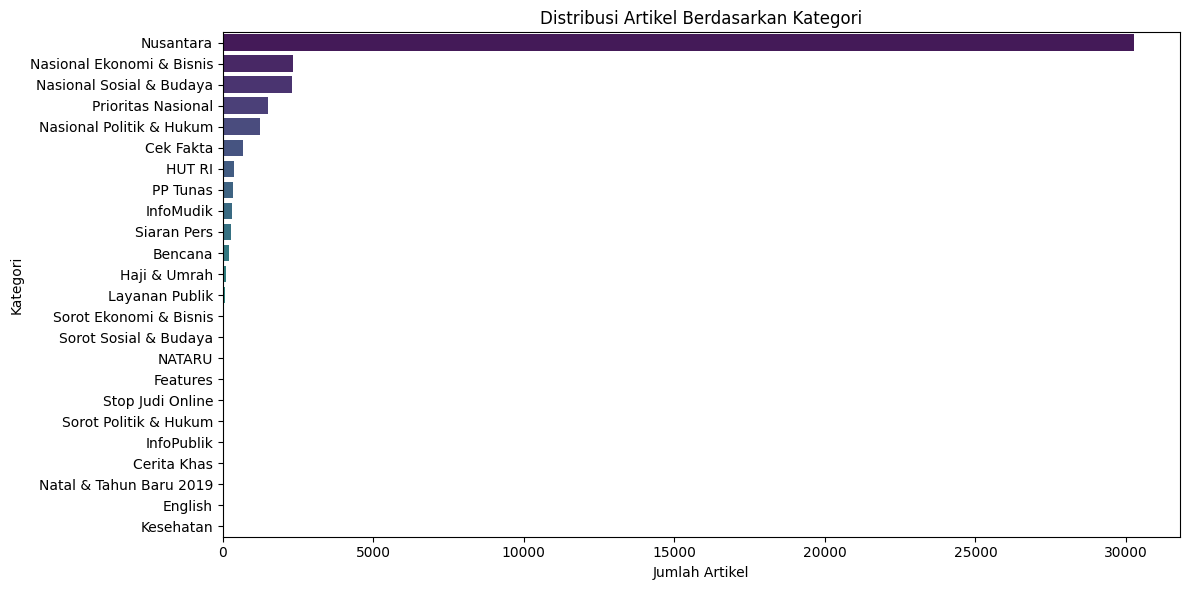

In [ ]:
# Preprocessing: Pastikan kolom tanggal dalam format datetime
df['tanggal'] = pd.to_datetime(df['tanggal'])

# 1. Analisis Jumlah Artikel per Kategori
plt.figure(figsize=(12, 6))
cat_order = df['kategori'].value_counts().index
sns.countplot(data=df, y='kategori', order=cat_order, palette='viridis')
plt.title('Distribusi Artikel Berdasarkan Kategori')
plt.xlabel('Jumlah Artikel')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

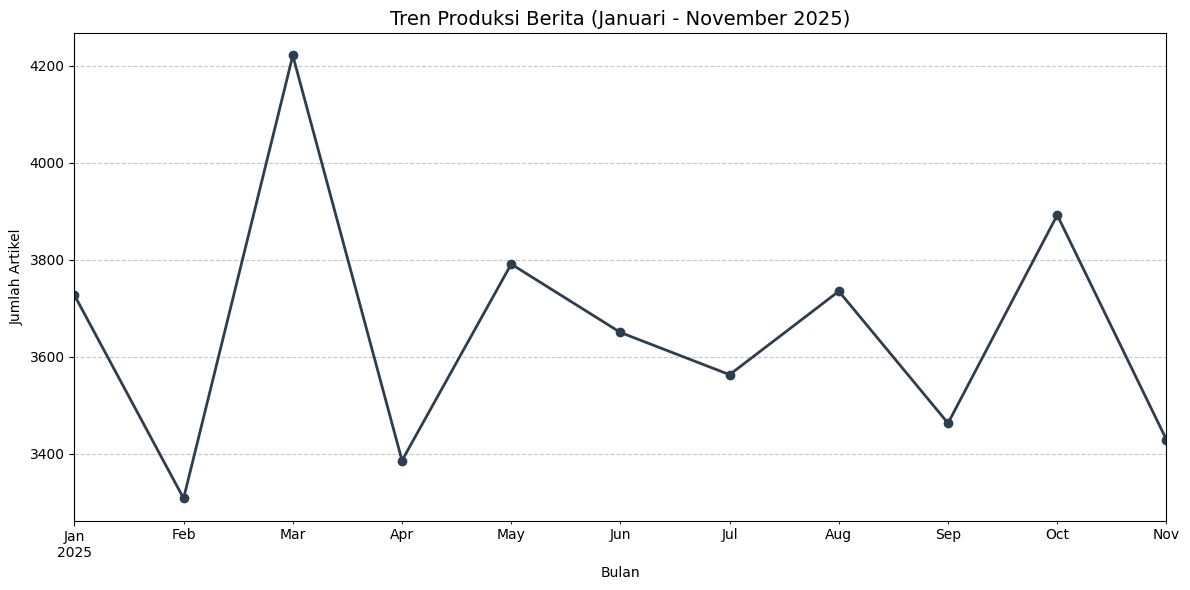

In [ ]:
# 2. Tren Produksi Berita Bulanan
df['bulan'] = df['tanggal'].dt.to_period('M')
monthly_counts = df.groupby('bulan').size()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='line', marker='o', linewidth=2, color='#2c3e50')
plt.title('Tren Produksi Berita (Januari - November 2025)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Jumlah Artikel')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

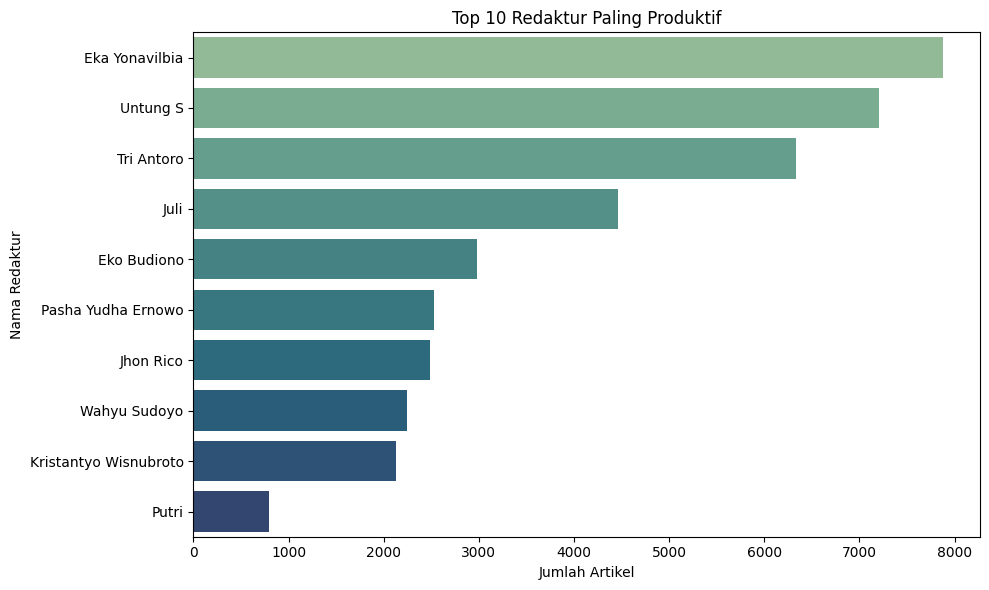

In [ ]:
# 3. Grafik Produktivitas Redaktur
top_redaktur = df['redaktur'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_redaktur.values, y=top_redaktur.index, hue=top_redaktur.index, palette='crest', legend=False)
plt.title('Top 10 Redaktur Paling Produktif')
plt.xlabel('Jumlah Artikel')
plt.ylabel('Nama Redaktur')
plt.tight_layout()
plt.show()

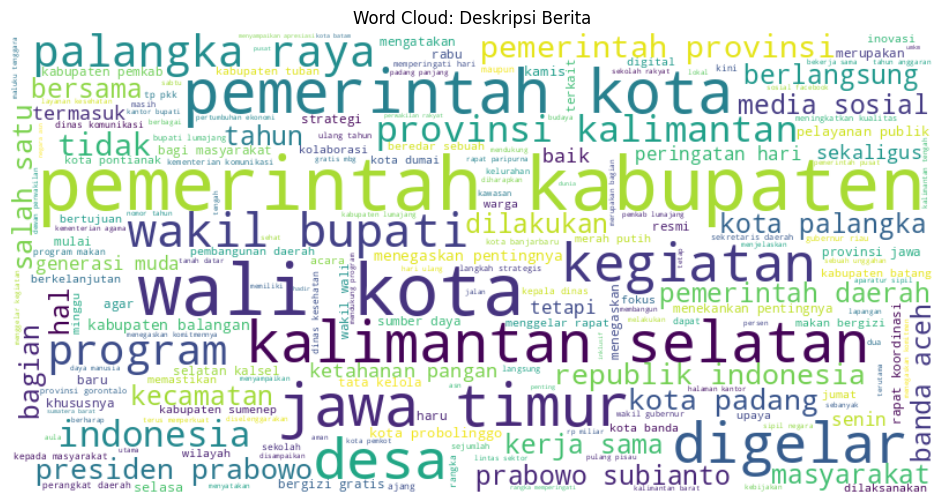

In [ ]:
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import re

# Daftar stopword bahasa Indonesia tambahan
indonesia_stopwords = {'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'ke', 'tersebut', 'dalam', 'bisa', 'ada', 'dengan', 'ia', 'bahwa', 'oleh', 'juga', 'akan', 'atau', 'ini', 'itu', 'saya', 'kami', 'kita', 'mereka', 'sebagai', 'adalah', 'menjadi', 'saat', 'telah', 'sudah', 'secara', 'karena', 'namun', 'maka', 'lebih', 'sangat', 'banyak', 'beberapa', 'hingga', 'setelah', 'seperti', 'bukan', 'hanya', 'antara', 'melalui', 'serta', 'yaitu', 'yakni'}

# 4. Word Cloud Deskripsi Berita
desc_text = " ".join(df['deskripsi_berita'].dropna().astype(str).tolist())
desc_text = re.sub(r'[^a-zA-Z\s]', '', desc_text).lower()

wc_desc = WordCloud(width=800, height=400, background_color='white', stopwords=indonesia_stopwords).generate(desc_text)
plt.figure(figsize=(12, 6))
plt.imshow(wc_desc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Deskripsi Berita')
plt.show()

In [ ]:
# 5. Word Cloud Isi Berita (Tanpa HTML)
def clean_body(text):
    if pd.isna(text): return ""
    soup = BeautifulSoup(str(text), 'html.parser')
    clean = soup.get_text(separator=' ')
    return re.sub(r'[^a-zA-Z\s]', '', clean).lower()

print("Memproses teks isi_berita (40rb+ baris)... Mohon tunggu.")
isi_text = " ".join(df['isi_berita'].apply(clean_body).tolist())

wc_isi = WordCloud(width=800, height=400, background_color='black', stopwords=indonesia_stopwords, colormap='YlGnBu').generate(isi_text)
plt.figure(figsize=(12, 6))
plt.imshow(wc_isi, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Isi Berita')
plt.show()

Memproses teks isi_berita (40rb+ baris)... Mohon tunggu.


KeyboardInterrupt: 

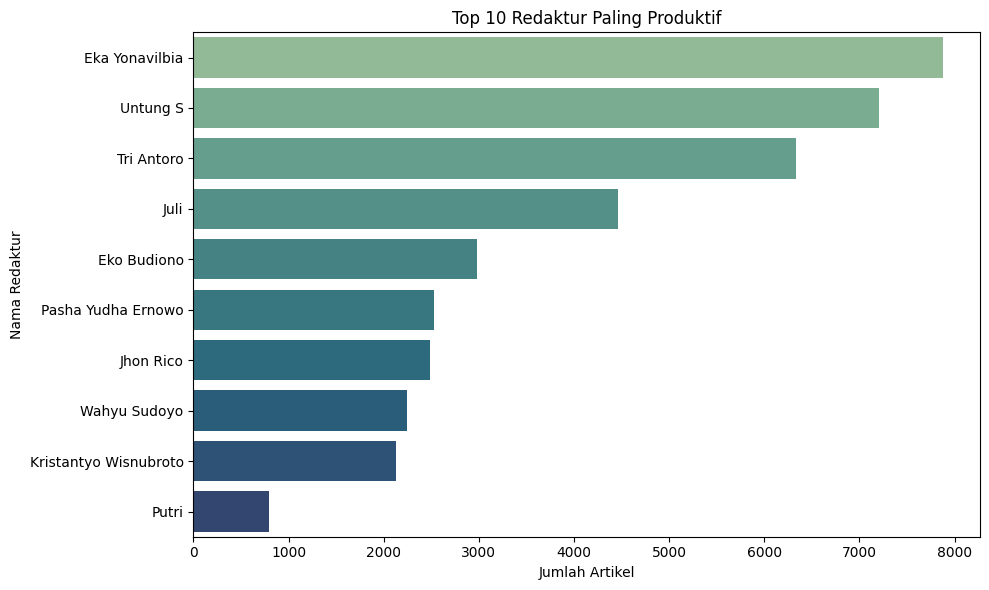

In [ ]:
# 3. Grafik Produktivitas Redaktur
top_redaktur = df['redaktur'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_redaktur.values, y=top_redaktur.index, hue=top_redaktur.index, palette='crest', legend=False)
plt.title('Top 10 Redaktur Paling Produktif')
plt.xlabel('Jumlah Artikel')
plt.ylabel('Nama Redaktur')
plt.tight_layout()
plt.show()

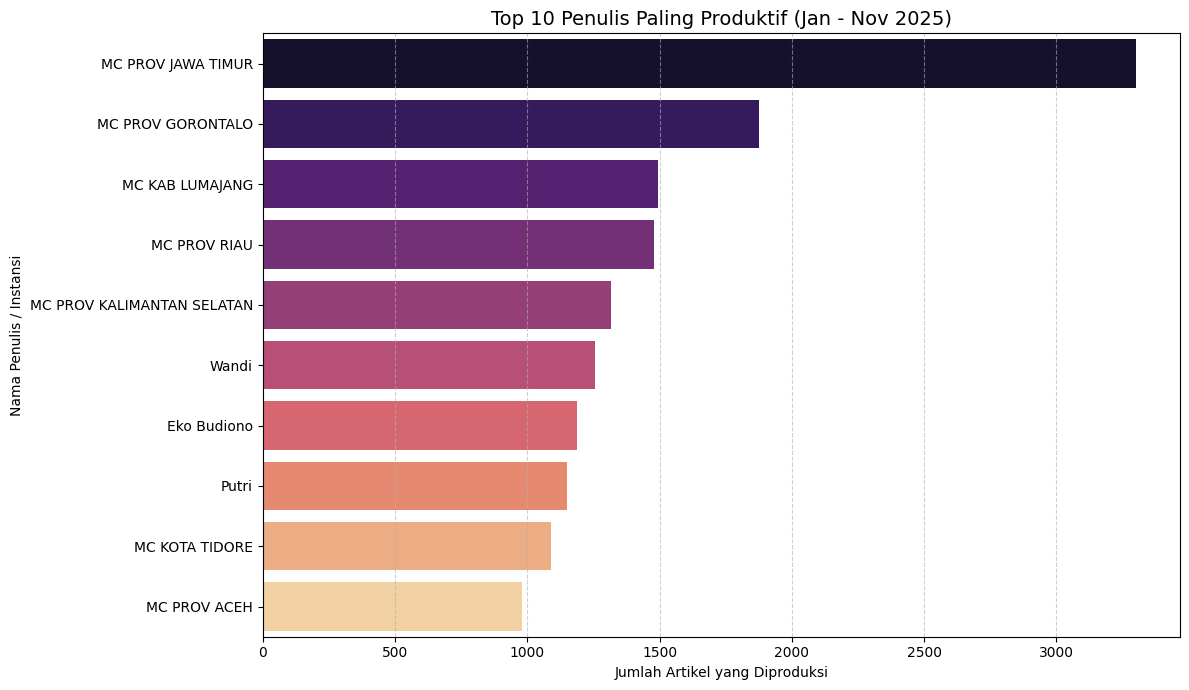

Detail Jumlah Artikel per Penulis (Top 10):
penulis
MC PROV JAWA TIMUR            3302
MC PROV GORONTALO             1876
MC KAB LUMAJANG               1494
MC PROV RIAU                  1479
MC PROV KALIMANTAN SELATAN    1315
Wandi                         1256
Eko Budiono                   1188
Putri                         1151
MC KOTA TIDORE                1091
MC PROV ACEH                   980
Name: count, dtype: int64


In [ ]:
# 6. Analisis Produktivitas Penulis
top_authors = df['penulis'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, palette='magma', legend=False)

plt.title('Top 10 Penulis Paling Produktif (Jan - Nov 2025)', fontsize=14)
plt.xlabel('Jumlah Artikel yang Diproduksi')
plt.ylabel('Nama Penulis / Instansi')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Menampilkan data dalam bentuk tabel sederhana
print("Detail Jumlah Artikel per Penulis (Top 10):")
print(top_authors)

In [ ]:
import requests
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re

def fetch_comprehensive_stopwords():
    urls = [
        "https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt",
        "https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt"
    ]
    stop_words = set()
    for url in urls:
        try:
            r = requests.get(url)
            if r.status_code == 200:
                stop_words.update(r.text.splitlines())
        except: continue
    manual_add = {"dan", "yang", "tetapi", "baik", "tidak", "ya", "dia", "ia", "kami", "kita", "mereka", "anda", "kamu", "adalah", "yaitu", "yakni", "infopublik", "jakarta", "berita", "terkait", "ujarnya", "katanya"}
    stop_words.update(manual_add)
    return stop_words

comprehensive_stopwords = fetch_comprehensive_stopwords()
print(f"Total stopwords: {len(comprehensive_stopwords)}")

In [ ]:
def clean_text(text, remove_html=False):
    if pd.isna(text): return ""
    if remove_html:
        text = BeautifulSoup(str(text), "html.parser").get_text(separator=" ")
    text = re.sub(r"[^a-zA-Z\s]", " ", text).lower()
    return text

print("Memproses Word Cloud Deskripsi...")
desc_cleaned = " ".join(df["deskripsi_berita"].apply(lambda x: clean_text(x, False)).tolist())
wc_desc = WordCloud(width=1000, height=600, background_color="white", stopwords=comprehensive_stopwords).generate(desc_cleaned)

plt.figure(figsize=(12, 6))
plt.imshow(wc_desc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Deskripsi Berita")
plt.show()

In [ ]:
print("Memproses Word Cloud Isi Berita (Pembersihan HTML)... Mohon tunggu.")
isi_cleaned = " ".join(df["isi_berita"].apply(lambda x: clean_text(x, True)).tolist())
wc_isi = WordCloud(width=1000, height=600, background_color="black", stopwords=comprehensive_stopwords, colormap="YlGnBu").generate(isi_cleaned)

plt.figure(figsize=(12, 6))
plt.imshow(wc_isi, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Isi Berita")
plt.show()

In [ ]:
import requests
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re

def fetch_comprehensive_stopwords():
    urls = [
        'https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt',
        'https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt'
    ]
    stop_words = set()
    for url in urls:
        try:
            r = requests.get(url)
            if r.status_code == 200:
                stop_words.update(r.text.splitlines())
        except: continue
    manual_add = {'dan', 'yang', 'tetapi', 'baik', 'tidak', 'ya', 'dia', 'ia', 'kami', 'kita', 'mereka', 'anda', 'kamu', 'adalah', 'yaitu', 'yakni', 'infopublik', 'jakarta', 'berita', 'terkait', 'ujarnya', 'katanya'}
    stop_words.update(manual_add)
    return stop_words

comprehensive_stopwords = fetch_comprehensive_stopwords()
print(f'Total stopwords: {len(comprehensive_stopwords)}')

In [ ]:
def clean_text(text, remove_html=False):
    if pd.isna(text): return ''
    if remove_html:
        text = BeautifulSoup(str(text), 'html.parser').get_text(separator=' ')
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    return text

print('Memproses Word Cloud Deskripsi...')
desc_cleaned = ' '.join(df['deskripsi_berita'].apply(lambda x: clean_text(x, False)).tolist())
wc_desc = WordCloud(width=1000, height=600, background_color='white', stopwords=comprehensive_stopwords).generate(desc_cleaned)

plt.figure(figsize=(12, 6))
plt.imshow(wc_desc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Deskripsi Berita')
plt.show()

In [ ]:
print('Memproses Word Cloud Isi Berita (Pembersihan HTML)...')
isi_cleaned = ' '.join(df['isi_berita'].apply(lambda x: clean_text(x, True)).tolist())
wc_isi = WordCloud(width=1000, height=600, background_color='black', stopwords=comprehensive_stopwords, colormap='YlGnBu').generate(isi_cleaned)

plt.figure(figsize=(12, 6))
plt.imshow(wc_isi, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Isi Berita')
plt.show()

In [ ]:
import requests
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re

# 1. Mengambil daftar stopwords dari referensi yang diminta
def fetch_comprehensive_stopwords():
    urls = [
        'https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt',
        'https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt'
    ]

    stop_words = set()
    for url in urls:
        try:
            r = requests.get(url)
            if r.status_code == 200:
                stop_words.update(r.text.splitlines())
        except:
            continue

    # Menambahkan kata ganti dan kata umum tambahan secara manual sesuai permintaan
    manual_add = {
        'dan', 'yang', 'tetapi', 'baik', 'tidak', 'ya', 'dia', 'ia', 'kami', 'kita', 'mereka',
        'anda', 'kamu', 'adalah', 'yaitu', 'yakni', 'infopublik', 'jakarta', 'berita'
    }
    stop_words.update(manual_add)
    return stop_words

comprehensive_stopwords = fetch_comprehensive_stopwords()
print(f"Total stopwords berhasil dimuat: {len(comprehensive_stopwords)}")

In [ ]:
# 2. Fungsi pembersihan untuk Deskripsi dan Isi Berita
def clean_text(text, remove_html=False):
    if pd.isna(text): return ""
    if remove_html:
        # Menghapus tag HTML menggunakan BeautifulSoup
        text = BeautifulSoup(str(text), "html.parser").get_text(separator=' ')
    # Menghapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    return text

# Memproses Deskripsi Berita
print("Memproses Deskripsi Berita...")
desc_cleaned = " ".join(df['deskripsi_berita'].apply(lambda x: clean_text(x, False)).tolist())

# Generate Word Cloud Deskripsi
wc_desc = WordCloud(width=1000, height=600, background_color='white',
                    stopwords=comprehensive_stopwords, colormap='viridis').generate(desc_cleaned)

plt.figure(figsize=(12, 7))
plt.imshow(wc_desc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Deskripsi Berita (Comprehensive Stopwords)', fontsize=15)
plt.show()

In [ ]:
# 3. Memproses Isi Berita
print("Memproses Isi Berita (Pembersihan HTML)... Mohon tunggu.")
# Karena data besar (40k baris), kita lakukan apply pembersihan
isi_cleaned = " ".join(df['isi_berita'].apply(lambda x: clean_text(x, True)).tolist())

# Generate Word Cloud Isi
wc_isi = WordCloud(width=1000, height=600, background_color='black',
                   stopwords=comprehensive_stopwords, colormap='YlGnBu').generate(isi_cleaned)

plt.figure(figsize=(12, 7))
plt.imshow(wc_isi, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Isi Berita (Clean HTML & Comprehensive Stopwords)', fontsize=15)
plt.show()

In [ ]:
import requests
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re

# Mengambil daftar stopwords dari beberapa sumber populer
def get_stopwords():
    # Sumber 1: masdevid/ID-Stopwords
    url1 = 'https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt'
    # Sumber 2: stopwords-iso
    url2 = 'https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt'

    stop_words = set()
    for url in [url1, url2]:
        try:
            r = requests.get(url)
            if r.status_code == 200:
                stop_words.update(r.text.splitlines())
        except:
            continue

    # Tambahan kata umum yang sering muncul di portal berita
    manual_add = {'infopublik', 'jakarta', 'indonesia', 'berita', 'terkait', 'ujarnya', 'katanya', 'saat', 'menurut'}
    stop_words.update(manual_add)
    return stop_words

id_stopwords = get_stopwords()
print(f"Total stopwords yang digunakan: {len(id_stopwords)}")

Total stopwords yang digunakan: 763


Memproses Deskripsi Berita...


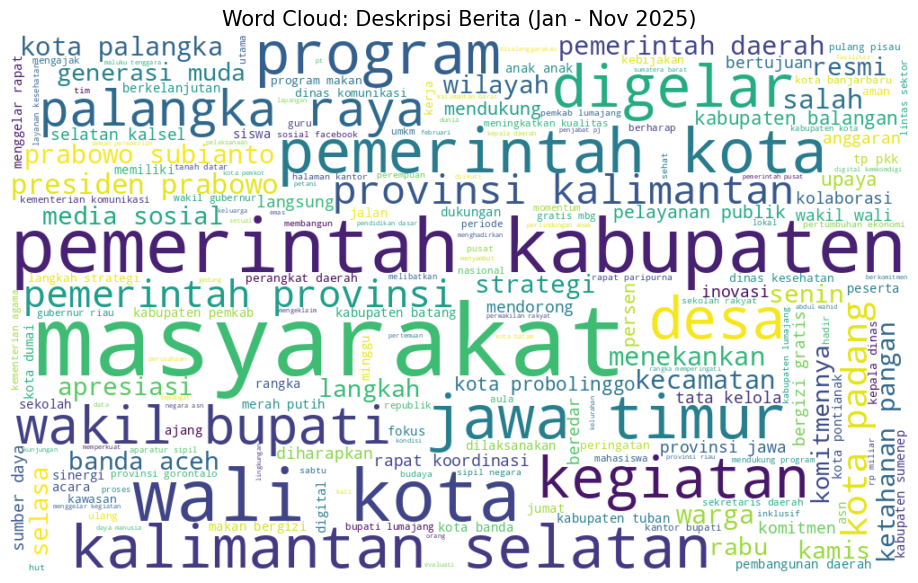

In [ ]:
# Fungsi pembersihan teks
def clean_text_data(text, is_html=False):
    if pd.isna(text): return ""
    if is_html:
        text = BeautifulSoup(str(text), "html.parser").get_text(separator=' ')
    # Hapus karakter non-alfabet dan angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    return text

# 1. Word Cloud Deskripsi Berita
print("Memproses Deskripsi Berita...")
desc_clean = " ".join(df['deskripsi_berita'].apply(lambda x: clean_text_data(x, False)).tolist())

wc_desc = WordCloud(width=1000, height=600, background_color='white', stopwords=id_stopwords, colormap='viridis').generate(desc_clean)

plt.figure(figsize=(12, 7))
plt.imshow(wc_desc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Deskripsi Berita (Jan - Nov 2025)', fontsize=15)
plt.show()

Memproses Isi Berita (Pembersihan HTML)... Mohon tunggu sebentar.


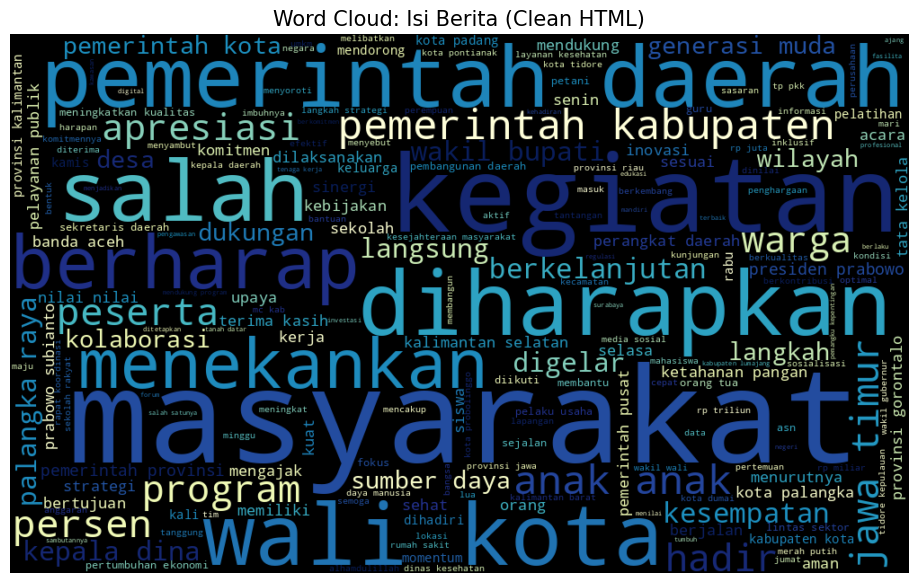

In [ ]:
# 2. Word Cloud Isi Berita
print("Memproses Isi Berita (Pembersihan HTML)... Mohon tunggu sebentar.")
# Menggunakan sampel 10rb baris jika data terlalu besar untuk mempercepat,
# namun di sini kita coba proses semua atau sampling jika perlu.
isi_clean = " ".join(df['isi_berita'].apply(lambda x: clean_text_data(x, True)).tolist())

wc_isi = WordCloud(width=1000, height=600, background_color='black', stopwords=id_stopwords, colormap='YlGnBu').generate(isi_clean)

plt.figure(figsize=(12, 7))
plt.imshow(wc_isi, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Isi Berita (Clean HTML)', fontsize=15)
plt.show()